# Imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from stability_gnn.data import load_dataset
from stability_gnn.model import make_predictions, test_and_evaluate, train_model
from stability_gnn.visualization import display_geo_map_optimized, plot_binned_grid, plot_state_grid
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_max_pool

# Loading the Model

## Defining the Model Architecture

In [2]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(3707)
        self.conv1 = GCNConv(365, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels) ## Same size to refine node embeddings
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 2)

    def forward(self, x, edge_index, batch):
        ## STEP 1: To obtain node embeddings
        x = self.conv1(x, edge_index) 
        x = F.dropout(x, p=0.3, training=self.training)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = F.dropout(x, p=0.3, training=self.training)

        ## STEP 2: Readout layer
        x = global_max_pool(x, batch) ## Computes batch wise mean of the graphs that have been batched. Returns one feature vector per batch

        ## STEP 3: Apply a final classifier
        x = F.dropout(x, p=0.3, training=self.training) ## Dropout is regularization to prevent overfitting
        x = self.lin(x)

        return x

## Loading the Weights

In [3]:
model = GCN(hidden_channels=64)
# # model.load_state_dict(torch.load('model_log_bias.pth'))
# model.load_state_dict(torch.load('model_vanilla.pth'))

# Variance Analysis

In [4]:
land_only_india_dataset = load_dataset(
    dataset_path='../../extracted_gsmap_isro_data/filtered_india_land_points.csv',
    bias=0,
    log_transform=False, ## The dataset is alread log-transformed since it was extracted from the original log-transformed dataset
    add_loc=False
)

...Loading Dataset...


In [5]:
land_only_india_dataset.head(10)

,LOC_ID,LONGITUDE,LATITUDE,VALID_POINTS,2015-01-01,2015-01-02,2015-01-03,2015-01-04,2015-01-05,2015-01-06,...,2022-12-22,2022-12-23,2022-12-24,2022-12-25,2022-12-26,2022-12-27,2022-12-28,2022-12-29,2022-12-30,2022-12-31
0,1059,68.25,23.65,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
1,1060,68.25,23.75,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
2,1360,68.35,23.65,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
3,1361,68.35,23.75,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
4,1362,68.35,23.85,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
5,1660,68.45,23.55,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
6,1661,68.45,23.65,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
7,1662,68.45,23.75,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
8,1663,68.45,23.85,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995
9,1664,68.45,23.95,70090,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995


In [6]:
land_only_india_dataset['RAINFALL_VARIANCE'] = land_only_india_dataset.iloc[:, 4:].var(axis=1)

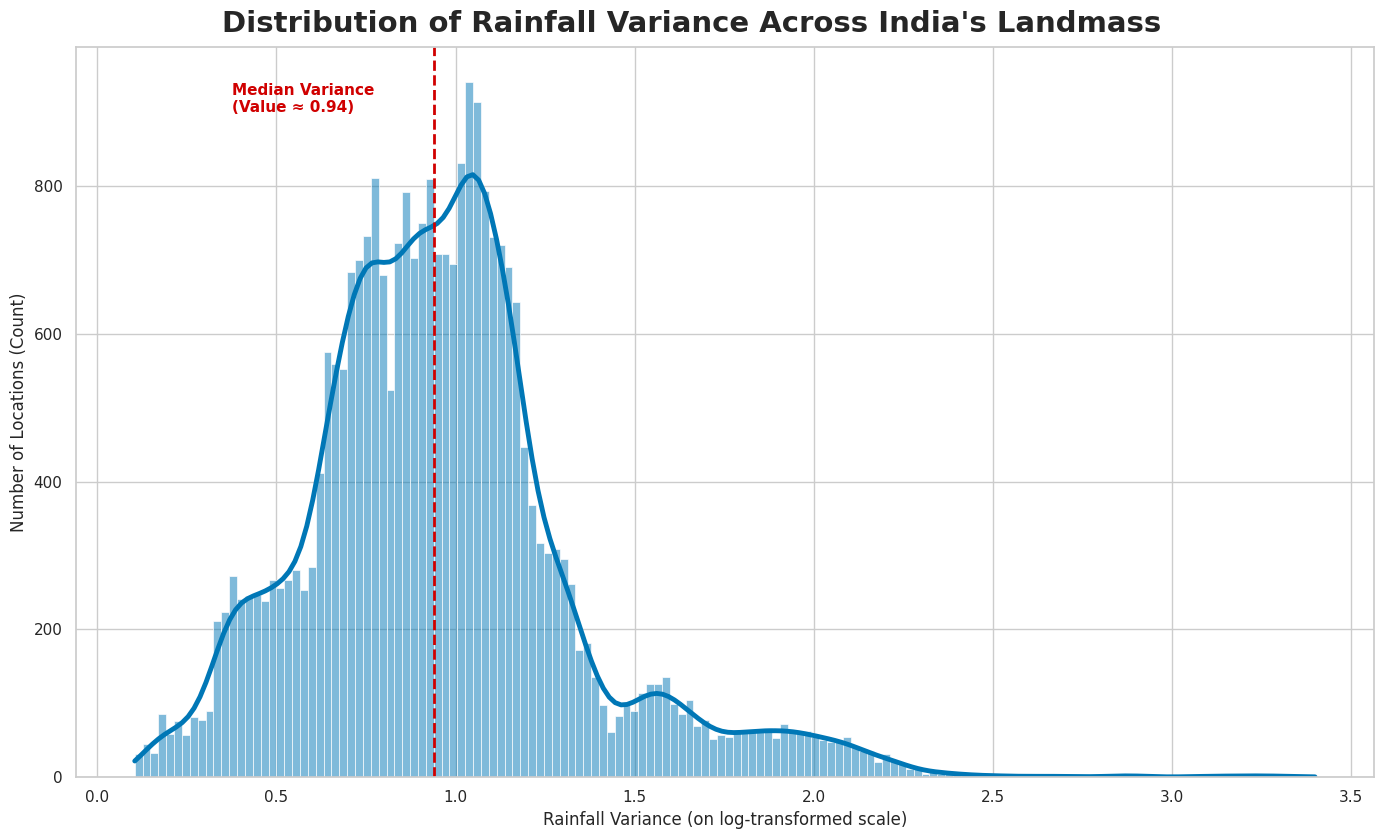

In [7]:
# To set a clean theme and a suitable figure size.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 9))

# To create the histogram with enhancements.
ax = sns.histplot(
    data=land_only_india_dataset,
    x='RAINFALL_VARIANCE',
    bins=150,  # Adjusted bins slightly for the new distribution
    color="#0077b6",  # A clear, accessible blue
    kde=True,
    line_kws={'linewidth': 3.5, 'color': '#03045e'}
)

# To add a descriptive title and a subtitle explaining the context.
plt.suptitle(
    "Distribution of Rainfall Variance Across India's Landmass",
    fontsize=21,
    fontweight='bold',
    y=0.93
)

# To add clear, descriptive axis labels.
ax.set_xlabel("Rainfall Variance (on log-transformed scale)", fontsize=12)
ax.set_ylabel("Number of Locations (Count)", fontsize=12)

# --- 3. Add Annotations to Tell the Story ---
# To find the median value to highlight the central tendency.
median_val = land_only_india_dataset['RAINFALL_VARIANCE'].median()
plt.axvline(x=median_val, color='#d00000', linestyle='--', linewidth=2)

# To add text that explains what the main peak represents.
plt.text(
    median_val * 0.4, 900, f'Median Variance\n(Value ≈ {median_val:.2f})',
    color='#d00000', fontsize=11, fontweight='bold'
)

# To finalize the layout and save the plot.
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('../images/land_only_rainfall_variance.png')
plt.show()

In [8]:
variance_sorted_land_only_india_dataset = land_only_india_dataset.sort_values(by='RAINFALL_VARIANCE', ascending=False).reset_index(drop=True)

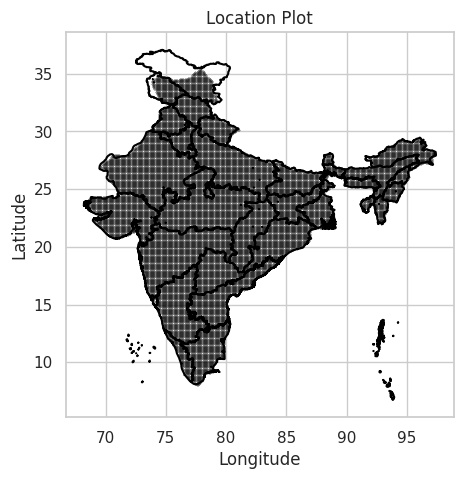

In [9]:
plot_state_grid(
    dataframe=land_only_india_dataset,
    savename='../images/land_only_gridpoints.png'
)

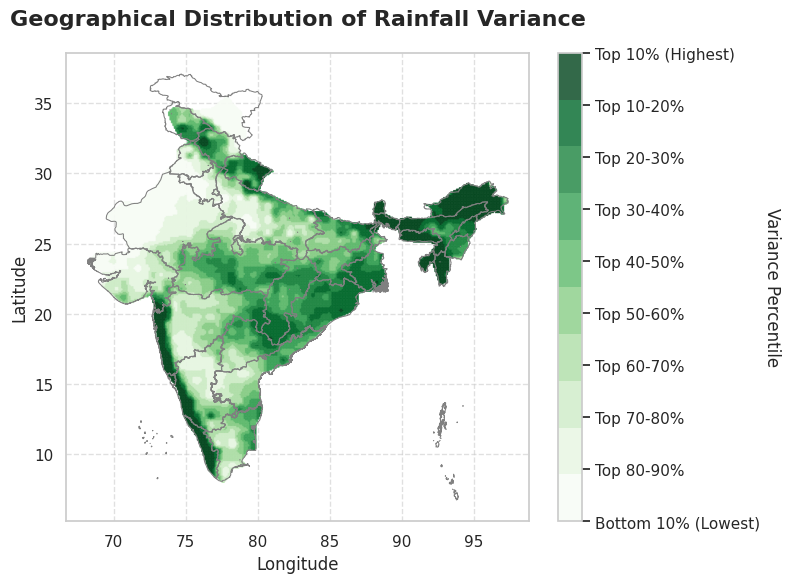

In [10]:
plot_binned_grid(
    dataframe=variance_sorted_land_only_india_dataset,
    colormap='Greens',
    savename='../images/land_only_rainfall_variance_map.png'
)

# Training

In [11]:
variance_sorted_land_only_india_dataset.head(10)

,LOC_ID,LONGITUDE,LATITUDE,VALID_POINTS,2015-01-01,2015-01-02,2015-01-03,2015-01-04,2015-01-05,2015-01-06,...,2022-12-24,2022-12-25,2022-12-26,2022-12-27,2022-12-28,2022-12-29,2022-12-30,2022-12-31,RAINFALL_VARIANCE,bin_id
0,70305,91.25,25.25,70090,0.00995,1.165286,0.372424,1.672279,0.517752,0.00995,...,0.00995,0.00995,2.202772,0.751710,0.00995,0.00995,0.00995,0.00995,3.399547,9
1,70004,91.15,25.25,70090,0.00995,1.174627,0.368012,1.680941,0.515394,0.00995,...,0.00995,0.00995,2.204174,0.761958,0.00995,0.00995,0.00995,0.00995,3.388977,9
2,69703,91.05,25.25,70090,0.00995,1.128565,0.343175,1.784134,0.560842,0.00995,...,0.00995,0.00995,2.188995,0.760591,0.00995,0.00995,0.00995,0.00995,3.333986,9
3,70606,91.35,25.25,70090,0.00995,1.013635,0.344938,1.799810,0.567839,0.00995,...,0.00995,0.00995,2.150195,0.688496,0.00995,0.00995,0.00995,0.00995,3.331964,9
4,70304,91.25,25.15,70090,0.00995,1.051924,0.345649,1.555150,0.479045,0.00995,...,0.00995,0.00995,2.148288,0.709240,0.00995,0.00995,0.00995,0.00995,3.303273,9
5,70003,91.15,25.15,70090,0.00995,1.060998,0.341229,1.567074,0.489067,0.00995,...,0.00995,0.00995,2.149823,0.770150,0.00995,0.00995,0.00995,0.00995,3.289642,9
6,70306,91.25,25.35,70090,0.00995,1.148237,0.352012,1.759869,0.522514,0.00995,...,0.00995,0.00995,2.168961,0.762399,0.00995,0.00995,0.00995,0.00995,3.274291,9
7,69402,90.95,25.25,70090,0.00995,0.907419,0.307292,1.909026,0.631655,0.00995,...,0.00995,0.00995,2.168052,0.752609,0.00995,0.00995,0.00995,0.00995,3.268676,9
8,70005,91.15,25.35,70090,0.00995,1.151941,0.349078,1.753784,0.494061,0.00995,...,0.00995,0.00995,2.170461,0.763392,0.00995,0.00995,0.00995,0.00995,3.268194,9
9,70605,91.35,25.15,70090,0.00995,0.591663,0.320580,1.670734,0.524993,0.00995,...,0.00995,0.00995,2.095713,0.646024,0.00995,0.00995,0.00995,0.00995,3.246637,9


In [12]:
variance_sorted_land_only_india_dataset.shape

(27829, 2928)

In [13]:
# --- 1. Define the Fixed Sample Size ---
# Set the desired number of samples (N) to take from *each* of the 10 bins.
N_SAMPLES_PER_BIN = 75 

# --- 2. Group the Data and Apply Sampling ---
# Use .groupby() to split the data by bin_id
# Use .sample() to randomly select N_SAMPLES_PER_BIN from each group
train_dataset = (
    variance_sorted_land_only_india_dataset.groupby('bin_id')
    .sample(
        n=N_SAMPLES_PER_BIN, 
        random_state=42, # Use random_state for reproducible sampling
        # 'replace=True' can be used if any bin has fewer than N_SAMPLES_PER_BIN
        # but for clean sampling, 'replace=False' (default) is best.
    )
    .reset_index(drop=True)
)

print(f"Total rows sampled: {len(train_dataset)}")
print(f"Expected rows: 10 bins * {N_SAMPLES_PER_BIN} samples = {10 * N_SAMPLES_PER_BIN} rows")
print("\nSample counts per bin in the new training set:")
# The output should show the same count for every bin_id
print(train_dataset['bin_id'].value_counts().sort_index())

Total rows sampled: 750
Expected rows: 10 bins * 75 samples = 750 rows

Sample counts per bin in the new training set:
bin_id
0    75
1    75
2    75
3    75
4    75
5    75
6    75
7    75
8    75
9    75
Name: count, dtype: int64


In [14]:
train_dataset.head(10)

,LOC_ID,LONGITUDE,LATITUDE,VALID_POINTS,2015-01-01,2015-01-02,2015-01-03,2015-01-04,2015-01-05,2015-01-06,...,2022-12-24,2022-12-25,2022-12-26,2022-12-27,2022-12-28,2022-12-29,2022-12-30,2022-12-31,RAINFALL_VARIANCE,bin_id
0,21888,75.15,29.65,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.357661,0
1,7704,70.45,25.95,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.321249,0
2,11008,71.55,25.25,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.387808,0
3,10411,71.35,25.75,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.385873,0
4,16766,73.45,29.15,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.264367,0
5,4676,69.45,24.15,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.470721,0
6,35700,79.75,26.25,70090,1.597633,1.330510,0.358055,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.419315,0
7,19173,74.25,29.05,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.383239,0
8,13742,72.45,27.75,70090,0.009950,0.009950,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.349651,0
9,23997,75.85,29.85,70090,0.009950,0.195022,0.009950,0.00995,0.00995,0.00995,...,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.00995,0.427625,0


...Training Model...
...Generating graphs: training_mode: True, threshold_percentile: 75...
...Making year wise dictionary...
...Making cosine similarity dictionary...


/home/prad/code/precipitation_gauge_gnn/code_files/model_notebooks/stability_gnn/data.py:131: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  tensor_data = torch.tensor(vectors, dtype=torch.float32)


...Making mean nodes...
...Making threshold dictionary...
...Making Graphs...
...Generating Labels...
...Computing Class Weights...
Epoch: 001, Train Accuracy: 0.8433, Validate Accuracy: 0.8333, Patience Counter: 0


/home/prad/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch: 002, Train Accuracy: 0.9500, Validate Accuracy: 0.9400, Patience Counter: 0
Epoch: 003, Train Accuracy: 0.9433, Validate Accuracy: 0.9400, Patience Counter: 0
Epoch: 004, Train Accuracy: 0.9533, Validate Accuracy: 0.9333, Patience Counter: 1
Epoch: 005, Train Accuracy: 0.9667, Validate Accuracy: 0.9467, Patience Counter: 2
Epoch: 006, Train Accuracy: 0.9633, Validate Accuracy: 0.9467, Patience Counter: 0
Epoch: 007, Train Accuracy: 0.9583, Validate Accuracy: 0.9400, Patience Counter: 1
Epoch: 008, Train Accuracy: 0.9700, Validate Accuracy: 0.9400, Patience Counter: 2
Epoch: 009, Train Accuracy: 0.9767, Validate Accuracy: 0.9533, Patience Counter: 3
Epoch: 010, Train Accuracy: 0.9867, Validate Accuracy: 0.9667, Patience Counter: 0
Epoch: 011, Train Accuracy: 0.9600, Validate Accuracy: 0.9333, Patience Counter: 0
Epoch: 012, Train Accuracy: 0.9900, Validate Accuracy: 0.9533, Patience Counter: 1
Epoch: 013, Train Accuracy: 0.9867, Validate Accuracy: 0.9533, Patience Counter: 2
Epoc

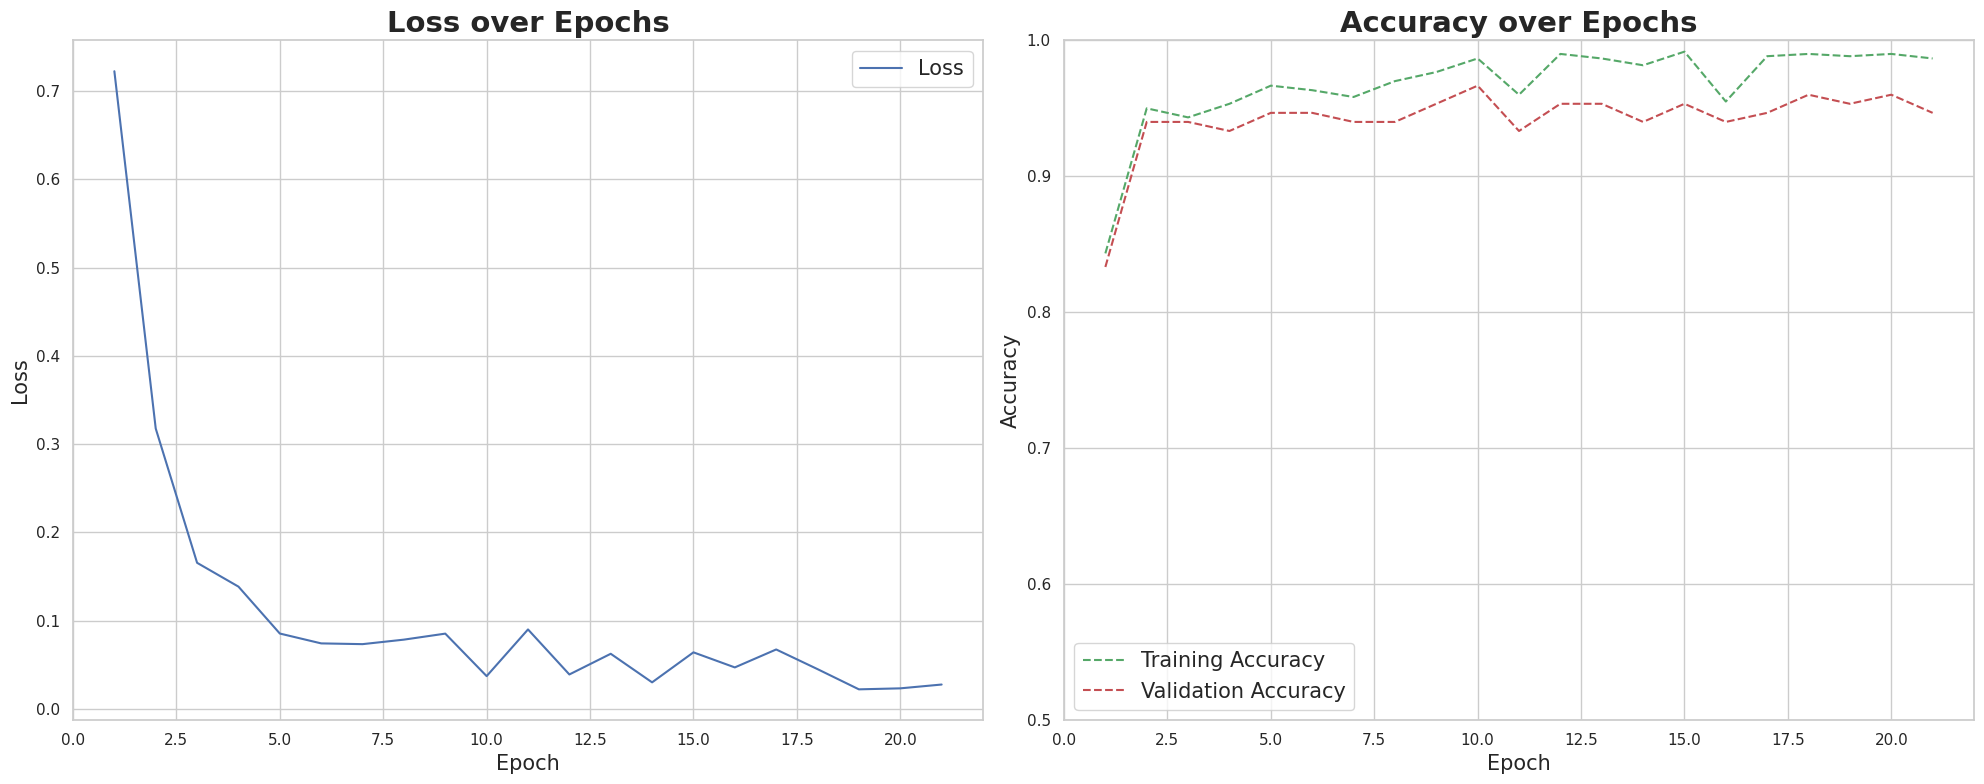

...Plotting t-SNE...


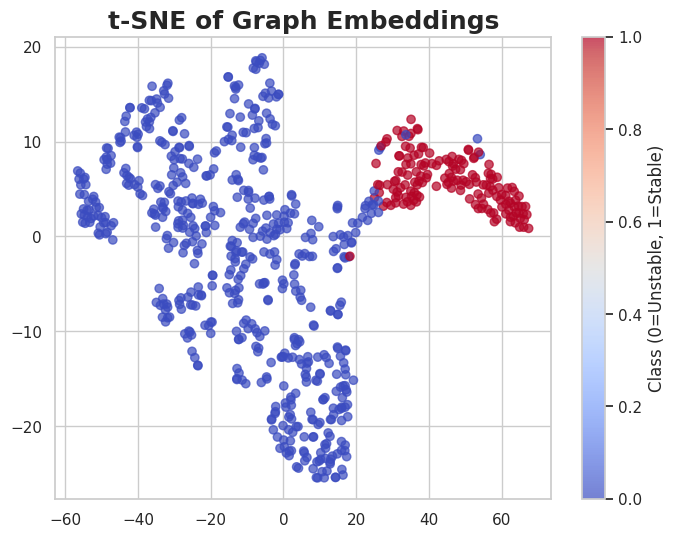

In [15]:
train_graphs, validation_graphs, graphs, threshold_value = train_model(
    train_dataframe=train_dataset,
    model=model,
    threshold_percentile=75
)

In [16]:
y_pred_validate = make_predictions(
    model=model,
    graphs=validation_graphs
)

...Making predictions...


In [17]:
y_pred_all = make_predictions(
    model=model,
    graphs=graphs
)

...Making predictions...


In [18]:
y_pred = list()
y_true = list()

for id, graph in validation_graphs.items():
    y_pred.append(y_pred_validate[id])
    y_true.append(graph.y.item())

print(len(y_pred))
print(len(y_true))

150
150


[[107   7]
 [  1  35]]

Classification Report:
              precision    recall  f1-score   support

    Unstable       0.99      0.94      0.96       114
      Stable       0.83      0.97      0.90        36

    accuracy                           0.95       150
   macro avg       0.91      0.96      0.93       150
weighted avg       0.95      0.95      0.95       150



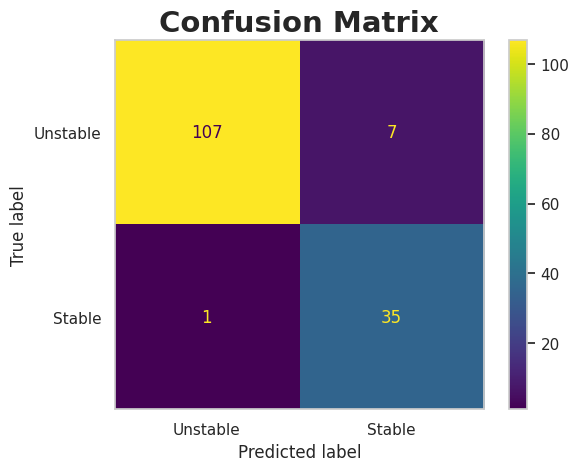

In [19]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=['Unstable', 'Stable']).plot()
plt.title('Confusion Matrix', fontsize=21, fontweight='bold')
plt.grid(False)
plt.savefig('../images/cm_validation.png')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Unstable', 'Stable']))

...Plotting geographical map...


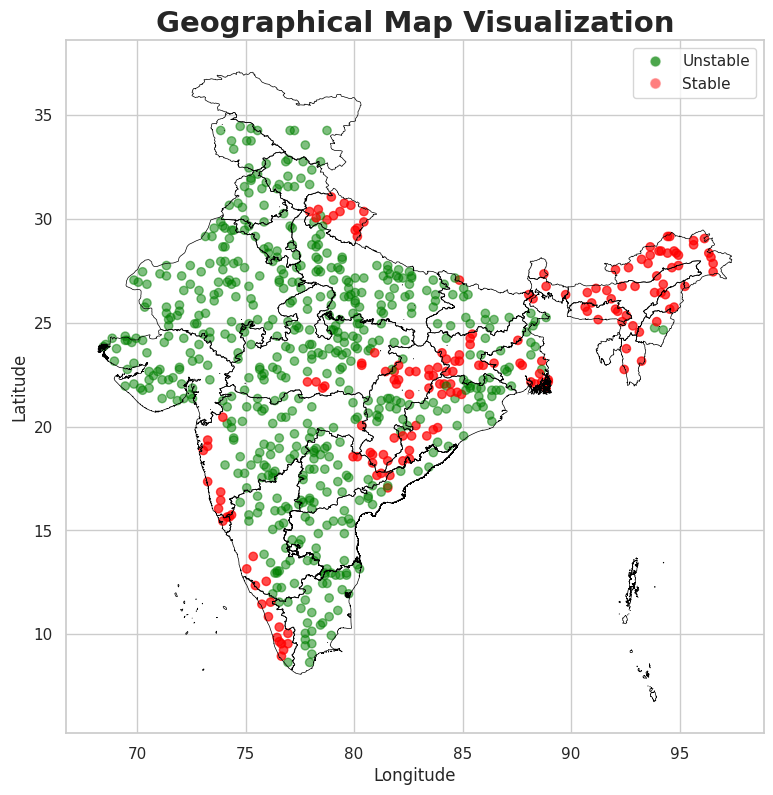

In [20]:
display_geo_map_optimized(
    dataframe=train_dataset,
    y_pred=y_pred_all,
    shapefile_path='/home/prad/code/precipitation_gauge_gnn/shapefiles/india/india_updated_state_boundary.shp',
    ids=graphs.keys(),
    transform=False,
    figsize=(9, 9),
    savename='../images/geo_map_training_and_validation.png'
)

# Testing

## Full India

...Generating graphs: training_mode: False, threshold_percentile: 75...
...Making year wise dictionary...
...Making cosine similarity dictionary...
...Making mean nodes...
...Making Graphs...
...Generating Labels...
...Making predictions...
...Getting true labels...
[[20899   690]
 [  355  5885]]

Classification Report:
              precision    recall  f1-score   support

    Unstable       0.98      0.97      0.98     21589
      Stable       0.90      0.94      0.92      6240

    accuracy                           0.96     27829
   macro avg       0.94      0.96      0.95     27829
weighted avg       0.96      0.96      0.96     27829

...Plotting geographical map...


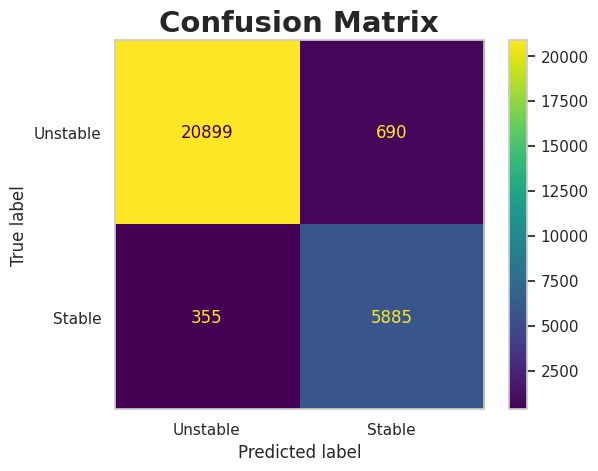

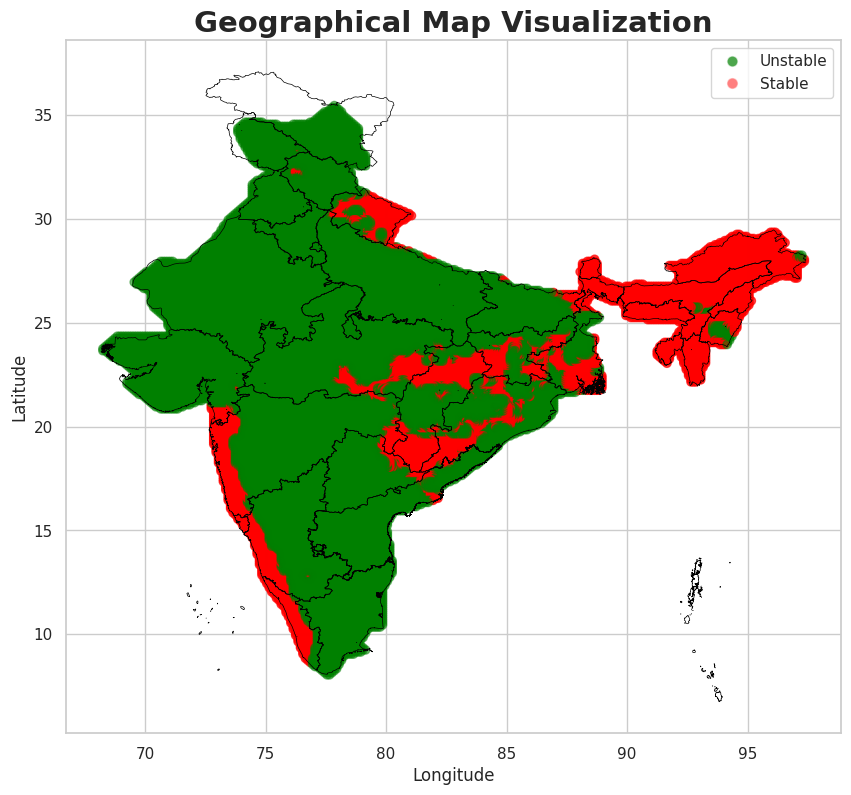

In [21]:
final_y_pred, final_y_true = test_and_evaluate(
    model=model,
    dataframe=variance_sorted_land_only_india_dataset,
    lat_range=None,
    lon_range=None,
    threshold_value=threshold_value,
    cm_savename='../images/cm_final.png',
    geo_map_savename='../images/geo_map_final.png'
)

In [22]:
df = variance_sorted_land_only_india_dataset.copy()

# Creating a new column 'prediction' that aligns the predictions with the DataFrame rows.
df['prediction'] = df['LOC_ID'].map(final_y_pred)

rainfall_data = df.iloc[:, 4:-3].copy() # Using -3 to exclude the newly added columns

# Calculating the mean and variance for each row (location) across the time series (axis=1).
all_means = rainfall_data.mean(axis=1)
all_variances = rainfall_data.var(axis=1)

# Stable mask: where the 'prediction' column is 1
stable_mask = (df['prediction'] == 1)

# Unstable mask: where the 'prediction' column is NOT 1
unstable_mask = (df['prediction'] != 1)

# Apply the masks to the pre-calculated Series and convert to lists
stable_mean = all_means[stable_mask].tolist()
stable_variance = all_variances[stable_mask].tolist()

unstable_mean = all_means[unstable_mask].tolist()
unstable_variance = all_variances[unstable_mask].tolist()

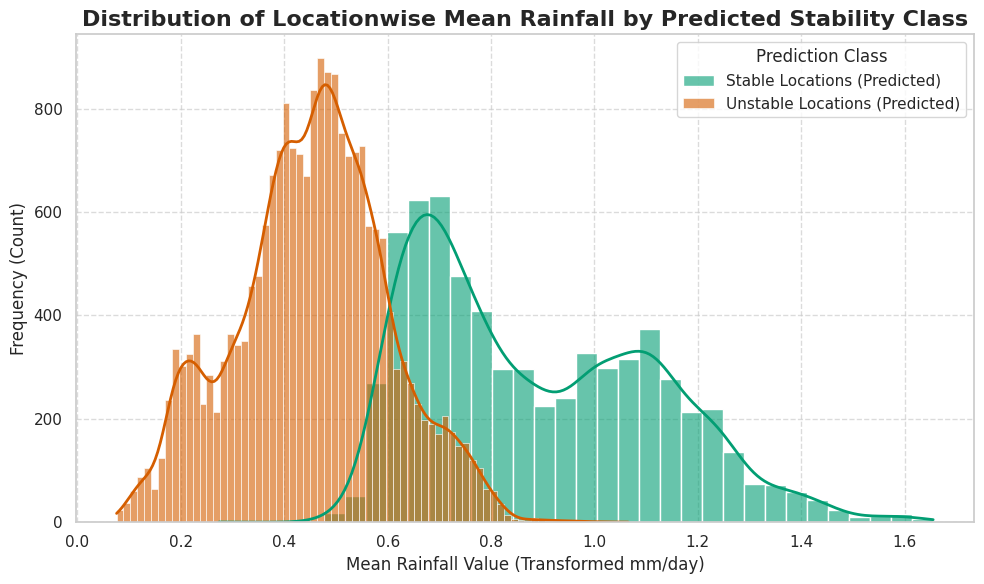

In [23]:
plt.figure(figsize=(10, 6))
sns.set_palette(sns.color_palette("colorblind")) 

sns.histplot(
    stable_mean, 
    label='Stable Locations (Predicted)', 
    color=sns.color_palette("colorblind")[2], # Green/Teal for stable
    alpha=0.6,
    kde=True, # Add Kernel Density Estimate for smooth curve
    line_kws={'linewidth': 2}
)
sns.histplot(
    unstable_mean, 
    label='Unstable Locations (Predicted)', 
    color=sns.color_palette("colorblind")[3], # Red/Orange for unstable
    alpha=0.6,
    kde=True,
    line_kws={'linewidth': 2}
)

# 3. Add Titles, Labels, and Legend
plot_title = 'Distribution of Locationwise Mean Rainfall by Predicted Stability Class'

# Apply plotting instructions
plt.title(plot_title, fontsize=16, fontweight='bold')

plt.xlabel("Mean Rainfall Value (Transformed mm/day)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)

plt.legend(title='Prediction Class', loc='best', frameon=True)

# 4. Final Touches
plt.grid(True, linestyle='--', alpha=0.7) # Add grid for readability
plt.tight_layout()
plt.savefig('../images/mean_by_class.png')
plt.show()

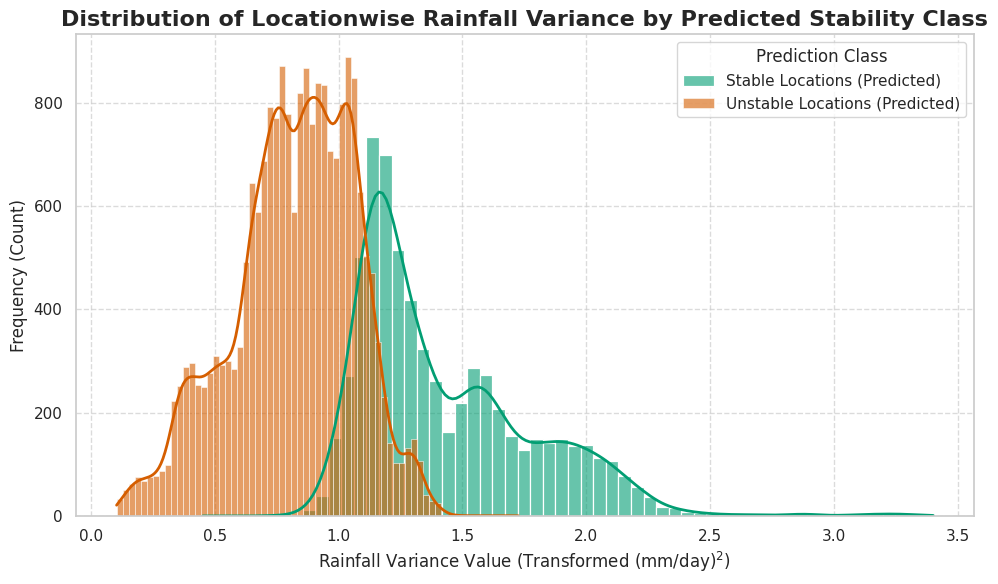

In [24]:
plt.figure(figsize=(10, 6))
sns.set_palette(sns.color_palette("colorblind")) 

sns.histplot(
    stable_variance, 
    label='Stable Locations (Predicted)', 
    color=sns.color_palette("colorblind")[2], # Green/Teal for stable
    alpha=0.6,
    kde=True, # Add Kernel Density Estimate for smooth curve
    line_kws={'linewidth': 2}
)
sns.histplot(
    unstable_variance, 
    label='Unstable Locations (Predicted)', 
    color=sns.color_palette("colorblind")[3], # Red/Orange for unstable
    alpha=0.6,
    kde=True,
    line_kws={'linewidth': 2}
)

# 3. Add Titles, Labels, and Legend
plot_title = 'Distribution of Locationwise Rainfall Variance by Predicted Stability Class'

# Apply plotting instructions
plt.title(plot_title, fontsize=16, fontweight='bold')

plt.xlabel("Rainfall Variance Value (Transformed (mm/day)$^2$)", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)

plt.legend(title='Prediction Class', loc='best', frameon=True)

# 4. Final Touches
plt.grid(True, linestyle='--', alpha=0.7) # Add grid for readability
plt.tight_layout()
plt.savefig('../images/variance_by_class.png')
plt.show()